<a href="https://colab.research.google.com/github/FFHS-BscCybersecurity/FFHS-AnPy/blob/main/AnPy_Semesterarbeit_Teil1_FS26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semesterarbeit Teil 1: Rekursion mit Python anhand der Fibonacci-Folge

Erstellt von: Peter Bickel-Hürlimann

## Einleitung

Diese Arbeit zeigt, wie man die bekannte Fibonacci-Folge in Python programmiert. Da es dafür verschiedene Lösungswege gibt, sind diese miteinander zu vergleichen. Das Hauptziel ist herauszufinden, wie sich eine einfache, sich selbst aufrufende (also: rekursive) Programmierung im Vergleich zu anderen Methoden (iterativ oder Formel von Binet) schlägt. Dabei schauen wir vor allem auf den Rechenaufwand und messen die benötigte Ausführungszeit.

## Theoretische Grundlagen

Die Fibonacci-Folge wurde erstmals von Leonardo Fibonacci als unendliche Folge natürlicher Zahlen definiert, die mit zweimal der Eins beginnt und bei der jede weitere Zahl die Summe der zwei vorangehenden Zahlen ist.

Mathematisch sieht das so aus: $$F_n = F_{n-1} + F_{n-2}$$ Dabei startet man mit $F_0 = 0$ und $F_1 = 1$. Wenn man diese Formel eins zu eins in Code übersetzt, nennt man das "Rekursion". Die Funktion ruft sich also selbst immer wieder auf. Das Problem dabei ist, dass viele Zwischenschritte unnötigerweise mehrfach berechnet werden.

Es gibt auch eine direkte mathematische Formel, die Formel von Binet. Damit lässt sich jede Fibonacci-Zahl sofort ausrechnen, ohne alle vorherigen zu berechnen:
$$F_n = \frac{1}{\sqrt{5}} \left( \left( \frac{1+\sqrt{5}}{2} \right)^n - \left( \frac{1-\sqrt{5}}{2} \right)^n \right)$$

Ein dritter Weg wäre der "iterative" Ansatz: Hier berechnet man die Zahlen einfach der Reihe nach von unten nach oben mit einer Schleife und merkt sich immer nur die letzten beiden Werte um weiter zu rechnen.

## Implementierungsidee


## Code

Plotten der Fibonacci-Zahlen und der Funktionsaufrufe


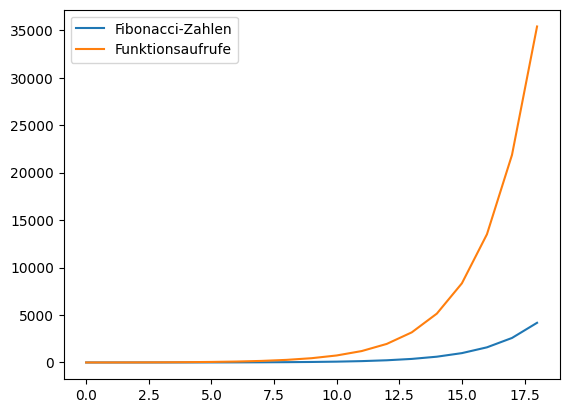

-------------------
Rekursive Implementierung:
6765
Dies ist die Laufzeit des Befehls fib(20) gemessen mit time()
Laufzeit in Sekunden: 0.004027366638183594
-------------------
Alternative Zeitmessung der selben Implementierung:
Dies ist die Laufzeit des Befehls fib(20) gemessen mit timeit()
Laufzeit in Sekunden: 0.003100132000000144
-------------------
Iterative Implementierung:
6765
Dies ist die Laufzeit des Befehls fib_iter(20) gemessen mit timeit()
Laufzeit in Sekunden: 4.825999994295671e-06
-------------------
Formel von Binet:
6765
Dies ist die Laufzeit des Befehls fib_binet(20) gemessen mit timeit()
Laufzeit in Sekunden: 6.0779999984106325e-06
-------------------


In [ ]:
######################################################
# 1. Bestimmen der n-ten Fibonacci-Zahl
######################################################
# Rekursive Implementierung
def fib(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    else:
        return fib(n - 1) + fib(n - 2)

######################################################
# 2. Bestimmen der Anzahl der Funktionsaufrufe
######################################################
# Gleiche Implementierung wie oben kopiert, nur mit zusätzlichem Zähler

# Globale Variable count
global count
count = 0

def fib_count(n):
    # Hier nochmals die Variable count als global deklariert, wegen des Scope
    global count
    # Erhöhen vom Zähler
    count += 1
    # Für 0 und 1 wird der Rückgabewert direkt zurückgegeben
    if n == 0:
        return 0
    if n == 1:
        return 1
    else:
        # Rekursiver Aufruf zur Berechnung der Fibonacci-Zahl
        fib = fib_count(n - 1) + fib_count(n - 2)
        # Rückgabe nur des Counters
        return count

######################################################
# 3. Ausgabe der Zahlen zum Vergleich (1-20)
######################################################
print("Plotten der Fibonacci-Zahlen und der Funktionsaufrufe")
import matplotlib.pyplot as plt
plt.plot([fib(n) for n in range(1, 20)], label="Fibonacci-Zahlen")
plt.plot([fib_count(n) for n in range(1, 20)], label="Funktionsaufrufe")
plt.legend()
plt.show()
print("-------------------")
######################################################
# 4. Laufzeiten
######################################################

import time # Aufgabenstellung
import timeit # Alternative


print("Rekursive Implementierung:")
# Start
start = time.time()
print(fib(20))
# Ende
end = time.time()
# Ausgabe time
print("Dies ist die Laufzeit des Befehls fib(20) gemessen mit time()")
print("Laufzeit in Sekunden:", end - start)
print("-------------------")
print("Alternative Zeitmessung der selben Implementierung:")
print("Dies ist die Laufzeit des Befehls fib(20) gemessen mit timeit()")
print("Laufzeit in Sekunden:", timeit.timeit("fib(20)", globals=globals(), number=1))
print("-------------------")
######################################################
# Alternative Implementierung
######################################################
# Dieses Mal iterativ
def fib_iter(n):
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a
print("Iterative Implementierung:")
print(fib_iter(20))

print("Dies ist die Laufzeit des Befehls fib_iter(20) gemessen mit timeit()")
print("Laufzeit in Sekunden:", timeit.timeit("fib_iter(20)", globals=globals(), number=1))

print("-------------------")
######################################################
# 5. Mit Formel von Binet (Recherche im Netz)
######################################################

import math

def fib_binet(n):
    return round((math.pow((1 + math.sqrt(5)) / 2, n) - math.pow((1 - math.sqrt(5)) / 2, n)) / math.sqrt(5))

print("Formel von Binet:")
print(fib_binet(20))

print("Dies ist die Laufzeit des Befehls fib_binet(20) gemessen mit timeit()")
print("Laufzeit in Sekunden:", timeit.timeit("fib_binet(20)", globals=globals(), number=1))
print("-------------------")

## Darstellung der Ergebnisse

Das Diagramm, sichtbar nach Ausführen des obigen Code-Blocks, vergleicht die  Fibonacci-Zahlen (y-Achse) mit der Anzahl der dafür nötigen Funktionsaufrufe bei der rekursiven Methode.

Zudem sind die gemessenen Laufzeiten, sortiert nach Implementierung, aufgeführt.

## Diskussion der Ergebnisse

Das Diagramm beantwortet die Frage aus der Aufgabenstellung sehr deutlich: Die Anzahl der Funktionsaufrufe bei der rekursiven Methode explodiert förmlich (exponentielle Kurve). Sie wächst viel schneller an als die Fibonacci-Zahlen selbst. Das liegt daran, dass sich die Funktion für jeden Schritt wie ein Baum verzweigt. Um zum Beispiel `fib(5)` zu berechnen, rechnet das Programm `fib(2)` gleich mehrfach aus. Dieser Aufwand wächst exponentiell.


Die Zeitmessungen bestätigen das zusätzlich. Die rekursive Methode braucht für $n=20$ bereits messbar Zeit. Die iterative Schleife und die Formel von Binet sind dagegen extrem schnell. Sie lösen das Problem fast ohne spürbare Verzögerung, da sie keine doppelten Berechnungen durchführen.

## Schlussfolgerungen und Ausblick

Die Rekursion ist für dieses Problem in der Praxis ungeeignet, weil er den Computer unnötig stark belastet und sehr langsam wird, obwohl es eine naheliegende Lösung wäre.

Die iterative Lösung mit einer Schleife ist in Python die beste Wahl. Sie ist schnell und rechnet genau. Die Formel von Binet ist zwar theoretisch ideal, kann aber bei sehr grossen Werten an seine Grenzen stossen und zu Rundungsfehlern führen.

## Quellen und Literatur

* Python Software Foundation. (2026). The Python Standard Library. Abgerufen von https://docs.python.org/3/library/
* Einführung in die Zahlentheorie. (2004). O. Forster. Abgerufen von https://www.mathematik.uni-muenchen.de/~forster/v/zth/inzth_01.pdf
* Recursive Functions. python-kurs.eu. Abgerufen von https://www.python-kurs.eu/python3_rekursive_funktionen.php
* Rechtschreibprüfung und Stil: Google Gemini
